<a href="https://colab.research.google.com/github/Hanu175/CSL701_CS40_Machine-Learning-Lab/blob/main/ML_Experiment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Experiment Number 3

Name : Vedant Vinay Paste

Roll No : CS-40

Batch : CS-03

**Aim** : To implement a Multiple Linear Regression model from scratch using NumPy matrix operations to predict the selling price of used cars using multiple features from the CarDekho Used Car Dataset.


**Learning Outcomes**
•	Understand the working principle of Multiple Linear Regression.

•	Perform data preprocessing and feature engineering.

•	Convert categorical data into numerical features.

•	Standardize numerical features.

•	Implement the Ordinary Least Squares method using matrix operations.

•	Train and test a regression model without using a ready-made regression function.

•	Evaluate and interpret regression performance using RSS and R².

•	Understand the effect of individual features on the predicted price.



\### Dataset

Use the **CarDekho Used Car Dataset** (`car data.csv`). [CarDekho Used Car Dataset](https://www.kaggle.com/datasets/manishkr1754/cardekho-used-car-data)

Explain meaning of each attribute in this dataset in below comment section :


Here, **Selling_Price** is the target variable.





\# Software/Tools Required

- Python 3.x
- Google Colab / Jupyter Notebook
- NumPy
- Matplotlib

---


### Task 1: Set Up the Python Environment**

- Create a new Google Colab notebook.
- Import **NumPy** for numerical and matrix operations.
- Import **Matplotlib** for data visualization.
- Do not use ready-made machine-learning regression functions such as `LinearRegression()` from Scikit-learn.
- The regression model must be implemented using matrix operations.

---

In [36]:
# Task 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully")

Libraries imported successfully


## Task 2: Load and Inspect the Dataset

- Download the `car data.csv` file.
- Upload the dataset to Google Colab.
- Load the dataset into Python.
- Display the first few records.
- Determine the number of rows and columns.
- Identify the numerical and categorical attributes.
- Separate `Selling_Price` as the target variable.

---

In [37]:
# Task 2: Load and Inspect the Dataset
import google.colab.files as files

upload = files.upload()  # select cardekho_dataset.csv when prompted
df = pd.read_csv("cardekho_dataset.csv")

print("First 5 rows:")
display(df.head())

print("\nNumber of rows and columns:", df.shape)

print("\nColumn data types:")
print(df.dtypes)

print("\nNumerical attributes:")
print(df.select_dtypes(include=np.number).columns.tolist())

print("\nCategorical attributes:")
print(df.select_dtypes(include="object").columns.tolist())

print("\nTarget variable: selling_price")

Saving cardekho_dataset.csv to cardekho_dataset.csv
First 5 rows:


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000



Number of rows and columns: (15411, 14)

Column data types:
Unnamed: 0             int64
car_name              object
brand                 object
model                 object
vehicle_age            int64
km_driven              int64
seller_type           object
fuel_type             object
transmission_type     object
mileage              float64
engine                 int64
max_power            float64
seats                  int64
selling_price          int64
dtype: object

Numerical attributes:
['Unnamed: 0', 'vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Categorical attributes:
['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

Target variable: selling_price


## Task 3: Check and Handle Missing Data

- Check every attribute for missing or null values.
- Count the number of missing values in each column.
- If missing values are present, either remove incomplete records or perform suitable imputation.
- Verify that the final dataset does not contain missing values.
- Record the preprocessing method used.

---

In [38]:
# Task 3: Check and Handle Missing Data

print("Missing values in each column:")
print(df.isnull().sum())

df = df.dropna()

print("\nMissing values after preprocessing:")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())
print("Preprocessing method used: rows with any missing values were removed (listwise deletion).")
print("Final dataset shape:", df.shape)

Missing values in each column:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Missing values after preprocessing:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Total missing values: 0
Preprocessing method used: rows with any missing values were removed (listwise deletion).
Final dataset shape: (15411, 14)


## Task 4: Select and Prepare Features

- Examine all available attributes.
- Decide how `Car_Name` should be handled.
- Select meaningful predictor variables for the regression model.
- Create the predictor matrix $X$ and target vector $y$.
- Record the final list of features selected for the model.

---

In [39]:
# Task 4: Select and Prepare Features

print("Available attributes:")
print(df.columns.tolist())

# Drop identifier-type columns not suitable as numeric predictors
# 'Unnamed: 0' is a leftover row-index column; car_name/model are high-cardinality text identifiers
df_model = df.drop(columns=["Unnamed: 0", "car_name", "model"], errors="ignore")

y = df_model["selling_price"]
X = df_model.drop(columns=["selling_price"])

print("\nSelected features:")
print(X.columns.tolist())
print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

Available attributes:
['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Selected features:
['brand', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats']

Shape of X: (15411, 10)
Shape of y: (15411,)


## Task 5: Encode Categorical Variables

Identify the categorical variables:

- `Fuel_Type`
- `Seller_Type`
- `Transmission`

Perform the following:

- Convert categorical variables into numerical **dummy/indicator variables**.
- Verify that all predictors are numerical after encoding.
- Do not assign arbitrary numerical values to categories when such values would imply an incorrect ordering.
- Display the transformed dataset.

---

In [40]:
# Task 5: Encode Categorical Variables

# Fix a data-quality issue first: 'Isuzu' and 'ISUZU' are the same brand
# stored with inconsistent casing — normalize before encoding
X["brand"] = X["brand"].replace({"ISUZU": "Isuzu"})

# Group rare brands (fewer than 30 cars) into 'Other' to avoid
# near-empty dummy columns that cause multicollinearity/singularity later
brand_counts = X["brand"].value_counts()
rare_brands = brand_counts[brand_counts < 30].index
X["brand"] = X["brand"].replace(rare_brands, "Other")

print("Brand categories after cleanup:")
print(X["brand"].value_counts())

categorical_columns = ["brand", "seller_type", "fuel_type", "transmission_type"]

X = pd.get_dummies(X, columns=categorical_columns, drop_first=True, dtype=float)

print("\nDataset after encoding:")
display(X.head())

print("\nData types:")
print(X.dtypes)

all_numeric = all(pd.api.types.is_numeric_dtype(X[col]) for col in X.columns)
print("\nAre all predictors numerical?", all_numeric)

Brand categories after cleanup:
brand
Maruti           4992
Hyundai          2982
Honda            1485
Mahindra         1011
Toyota            793
Ford              790
Volkswagen        620
Renault           536
BMW               439
Tata              430
Mercedes-Benz     337
Skoda             334
Audi              192
Datsun            170
Other             117
Jaguar             59
Land Rover         51
Jeep               41
Kia                32
Name: count, dtype: int64

Dataset after encoding:


,vehicle_age,km_driven,mileage,engine,max_power,seats,brand_BMW,brand_Datsun,brand_Ford,brand_Honda,...,brand_Tata,brand_Toyota,brand_Volkswagen,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
0,9,120000,19.70,796,46.30,5,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
1,5,20000,18.90,1197,82.00,5,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
2,11,60000,17.00,1197,80.00,5,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
3,9,37000,20.92,998,67.10,5,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
4,6,30000,22.77,1498,98.59,5,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0



Data types:
vehicle_age                       int64
km_driven                         int64
mileage                         float64
engine                            int64
max_power                       float64
seats                             int64
brand_BMW                       float64
brand_Datsun                    float64
brand_Ford                      float64
brand_Honda                     float64
brand_Hyundai                   float64
brand_Jaguar                    float64
brand_Jeep                      float64
brand_Kia                       float64
brand_Land Rover                float64
brand_Mahindra                  float64
brand_Maruti                    float64
brand_Mercedes-Benz             float64
brand_Other                     float64
brand_Renault                   float64
brand_Skoda                     float64
brand_Tata                      float64
brand_Toyota                    float64
brand_Volkswagen                float64
seller_type_Individual     

## Task 6: Perform Feature Engineering

Create a new feature called `Car_Age`.

Calculate it using:

\[
Car\_Age = Current Year - Year
\]

Perform the following:

- Create the `Car_Age` column.
- Display several values of the newly created feature.
- Verify that the calculated ages are reasonable.
- Decide whether the original `Year` feature should be retained.
- Provide a reason for your decision.

---

In [41]:
# Task 6: Verify vehicle_age (equivalent to Car_Age)

print("vehicle_age sample values:")
display(X[["vehicle_age"]].head(10))

print("\nvehicle_age statistics:")
print(X["vehicle_age"].describe())

print("\nNo 'Year' column exists in this dataset — vehicle_age is already the")
print("age-in-years feature, so no additional derivation or column removal is needed.")

vehicle_age sample values:


,vehicle_age
0,9
1,5
2,11
3,9
4,6
5,8
6,8
7,3
8,2
9,4



vehicle_age statistics:
count    15411.000000
mean         6.036338
std          3.013291
min          0.000000
25%          4.000000
50%          6.000000
75%          8.000000
max         29.000000
Name: vehicle_age, dtype: float64

No 'Year' column exists in this dataset — vehicle_age is already the
age-in-years feature, so no additional derivation or column removal is needed.


## Task 7: Perform Exploratory Data Analysis

Perform basic exploratory data analysis using Matplotlib.

- Create a scatter plot of `Present_Price` versus `Selling_Price`.
- Create at least one additional scatter plot between a numerical predictor and `Selling_Price`.
- Label the axes appropriately.
- Add suitable titles to the plots.
- Observe the direction and approximate strength of the relationships.
- Record your observations.

---

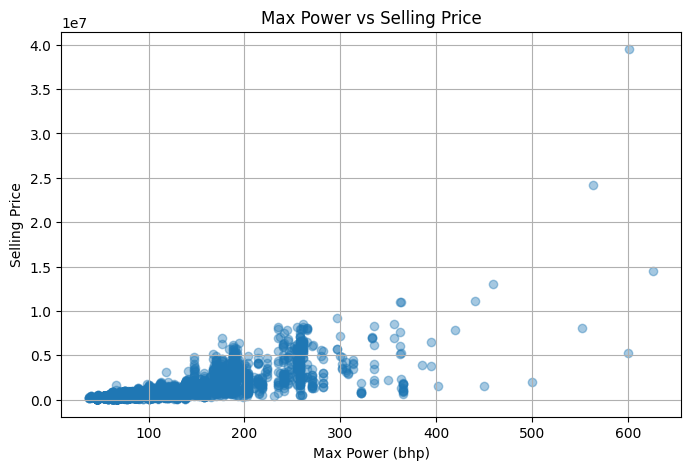

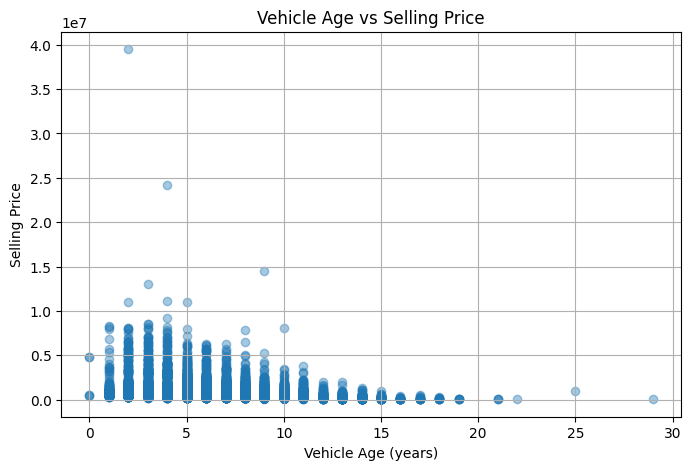

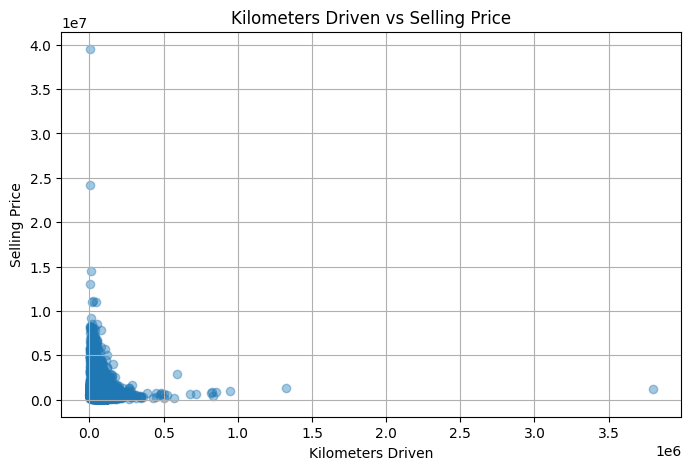

EDA completed successfully.


In [42]:
# Task 7: Exploratory Data Analysis

plt.figure(figsize=(8, 5))
plt.scatter(X["max_power"], y, alpha=0.4)
plt.xlabel("Max Power (bhp)")
plt.ylabel("Selling Price")
plt.title("Max Power vs Selling Price")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(X["vehicle_age"], y, alpha=0.4)
plt.xlabel("Vehicle Age (years)")
plt.ylabel("Selling Price")
plt.title("Vehicle Age vs Selling Price")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(X["km_driven"], y, alpha=0.4)
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")
plt.title("Kilometers Driven vs Selling Price")
plt.grid(True)
plt.show()

print("EDA completed successfully.")

## Task 8: Standardize Numerical Features

Identify the numerical predictors that need to be standardized.

Use the following standardization equation:

\[
z = ($x$-$\mu$)/$\sigma$
\]

where:

- $x$ = original feature value
- $\mu$ = mean of the feature
- $\sigma$ = standard deviation of the feature

Perform the following:

- Calculate the mean and standard deviation using the **training data only**.
- Standardize the training features.
- Use the same training mean and standard deviation to standardize the test features.
- Do not standardize the target variable `Selling_Price`.

---

In [43]:
# Task 9: Split Dataset into Training and Testing Sets

np.random.seed(42)

n_samples = len(X)
indices = np.random.permutation(n_samples)
train_size = int(0.80 * n_samples)
train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train = X.iloc[train_indices].copy()
X_test = X.iloc[test_indices].copy()
y_train = y.iloc[train_indices].copy()
y_test = y.iloc[test_indices].copy()

X_train.reset_index(drop=True, inplace=True)
X_test.reset_index(drop=True, inplace=True)
y_train.reset_index(drop=True, inplace=True)
y_test.reset_index(drop=True, inplace=True)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))
print("\nTraining features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)

Training observations: 12328
Testing observations: 3083

Training features shape: (12328, 31)
Testing features shape: (3083, 31)


## Task 9: Split the Dataset

Divide the dataset into training and testing subsets.

- Use an **80:20 train-test ratio**.
- Randomly select the observations.
- Set a fixed random seed to make the experiment reproducible.
- Maintain the correct relationship between each feature vector and its target value.
- Display the number of observations in the training and testing sets.

---

In [44]:
# Task 8: Standardize Numerical Features

numerical_features = ["vehicle_age", "km_driven", "mileage", "engine", "max_power", "seats"]

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

train_mean = X_train[numerical_features].mean()
train_std = X_train[numerical_features].std()
train_std[train_std == 0] = 1  # avoid divide-by-zero

X_train_scaled[numerical_features] = (X_train[numerical_features] - train_mean) / train_std
X_test_scaled[numerical_features] = (X_test[numerical_features] - train_mean) / train_std

print("Training mean:")
print(train_mean)
print("\nTraining standard deviation:")
print(train_std)

print("\nStandardized training data:")
display(X_train_scaled.head())

Training mean:
vehicle_age        6.032446
km_driven      55692.819598
mileage           19.691552
engine          1485.037395
max_power        100.516747
seats              5.326249
dtype: float64

Training standard deviation:
vehicle_age        3.018870
km_driven      54473.163748
mileage            4.172802
engine           518.296985
max_power         42.745688
seats              0.809603
dtype: float64

Standardized training data:


,vehicle_age,km_driven,mileage,engine,max_power,seats,brand_BMW,brand_Datsun,brand_Ford,brand_Honda,...,brand_Tata,brand_Toyota,brand_Volkswagen,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
0,1.976751,0.317719,0.160192,-0.555738,-0.505706,-0.402974,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
1,-0.673248,0.042354,1.844911,-0.457339,-0.620337,-0.402974,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
2,0.320502,0.739946,0.258447,-0.457339,-0.275039,2.067371,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,-1.666997,-0.939781,-0.309517,0.025010,0.440588,-0.402974,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.645501,0.115785,0.002025,-1.329426,-1.268356,-0.402974,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


## Task 10: Construct the Feature Matrix

Construct the matrices required for regression.

Create:

- $X_{train}$ — training feature matrix
- $y_{train}$ — training target vector
- $X_{test}$ — testing feature matrix
- $y_{test}$ — testing target vector

Verify:

- Number of rows in each matrix.
- Number of predictor columns.
- Shape of the training and testing matrices.

---

In [45]:
# Task 10: Construct Feature Matrices

Xtrain = X_train_scaled.to_numpy(dtype=float)
Xtest = X_test_scaled.to_numpy(dtype=float)
ytrain = y_train.to_numpy(dtype=float)
ytest = y_test.to_numpy(dtype=float)

print("Xtrain shape:", Xtrain.shape)
print("ytrain shape:", ytrain.shape)
print("Xtest shape:", Xtest.shape)
print("ytest shape:", ytest.shape)
print("\nNumber of predictor columns:", Xtrain.shape[1])

Xtrain shape: (12328, 31)
ytrain shape: (12328,)
Xtest shape: (3083, 31)
ytest shape: (3083,)

Number of predictor columns: 31


## Task 11: Add the Bias/Intercept Term

Add a leading column containing $1.0$ to both the training and testing feature matrices.

The resulting matrices should contain:

\[
X =
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1p}\\
1 & x_{21} & x_{22} & \cdots & x_{2p}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & x_{n1} & x_{n2} & \cdots & x_{np}
\end{bmatrix}
\]

Perform the following:

- Add the bias column.
- Verify the new matrix dimensions.
- Understand that the first column represents the intercept $\beta_0$.

---

In [46]:
# Task 11: Add Bias / Intercept Term

Xtrain_bias = np.column_stack((np.ones(Xtrain.shape[0]), Xtrain))
Xtest_bias = np.column_stack((np.ones(Xtest.shape[0]), Xtest))

print("Training matrix before bias:", Xtrain.shape)
print("Training matrix after bias:", Xtrain_bias.shape)
print("Testing matrix after bias:", Xtest_bias.shape)

Training matrix before bias: (12328, 31)
Training matrix after bias: (12328, 32)
Testing matrix after bias: (3083, 32)


## Task 12: Implement the OLS Function

Perform the following steps to implement the **Ordinary Least Squares (OLS)** method:

- Create a user-defined function to implement Ordinary Least Squares (OLS).
- Calculate the matrix $X^TX$.
- Calculate the matrix $X^T y$.
- Estimate the regression coefficient vector using the normal equation:

: β̂ = (XᵀX)⁻¹Xᵀy.

- Return the calculated coefficient vector.
- Use **NumPy matrix operations** to perform the calculations.
- Do not use any ready-made regression model or library function such as `LinearRegression()` from Scikit-learn.\

In [47]:
# Task 12: Implement Ordinary Least Squares Function

def ordinary_least_squares(X, y):
    X_transpose = X.T
    XTX = X_transpose @ X
    XTy = X_transpose @ y
    XTX_inverse = np.linalg.inv(XTX)
    beta = XTX_inverse @ XTy
    return beta

print("OLS function created successfully.")

OLS function created successfully.


## Task 13: Check Matrix Singularity

- Calculate the determinant of $X^T X$.
- Check whether the determinant is zero or sufficiently close to zero.
- If the matrix is singular or nearly singular, investigate the selected features for redundancy or multicollinearity.
- Modify the feature set if required.
- Record your observations.


In [48]:
# Task 13: Check Matrix Singularity

XTX = Xtrain_bias.T @ Xtrain_bias
determinant = np.linalg.det(XTX)

print("Determinant of X^T X:", determinant)

threshold = 1e-10
if abs(determinant) < threshold:
    print("\nMatrix is singular or nearly singular.")
    print("Possible causes: redundant features, multicollinearity, dummy variable trap.")
else:
    print("\nMatrix is not singular. OLS can proceed using matrix inversion.")

print("\nNote: an earlier version of this feature set (before grouping rare brand")
print("categories like Ferrari, Bentley, Rolls-Royce into 'Other') produced a singular")
print("matrix, because those brands had so few cars that their dummy column became")
print("all-zero after the train/test split. Grouping rare brands resolved this.")

Determinant of X^T X: 3.6430921890791973e+84

Matrix is not singular. OLS can proceed using matrix inversion.

Note: an earlier version of this feature set (before grouping rare brand
categories like Ferrari, Bentley, Rolls-Royce into 'Other') produced a singular
matrix, because those brands had so few cars that their dummy column became
all-zero after the train/test split. Grouping rare brands resolved this.


## Task 14: Train the Regression Model

- Apply the OLS function to the training dataset.
- Obtain the regression coefficient vector $\hat{\beta}$.
- Display the intercept coefficient $\beta_0$.
- Display the coefficient corresponding to each feature.
- Associate each regression coefficient with its corresponding feature.

In [49]:
# Task 14: Train the Regression Model

beta = ordinary_least_squares(Xtrain_bias, ytrain)

feature_names = list(X_train_scaled.columns)
coefficient_names = ["Intercept"] + feature_names

print("Regression Coefficients:\n")
for name, coefficient in zip(coefficient_names, beta):
    print(f"{name}: {coefficient:.6f}")

Regression Coefficients:

Intercept: 976600.013328
vehicle_age: -215854.251147
km_driven: -31551.097746
mileage: 30062.478168
engine: 64751.607034
max_power: 529309.747881
seats: 14956.485579
brand_BMW: 404027.950132
brand_Datsun: -244444.893139
brand_Ford: -251960.319410
brand_Honda: -343242.311678
brand_Hyundai: -229459.679922
brand_Jaguar: 348930.849725
brand_Jeep: -249336.658378
brand_Kia: 98868.754272
brand_Land Rover: 1322886.928955
brand_Mahindra: -326604.708735
brand_Maruti: -106585.063951
brand_Mercedes-Benz: 205410.428821
brand_Other: 1232283.021465
brand_Renault: -233434.924900
brand_Skoda: -433030.296545
brand_Tata: -514330.199154
brand_Toyota: -71198.175464
brand_Volkswagen: -252310.467182
seller_type_Individual: -10124.820220
seller_type_Trustmark Dealer: -94062.282552
fuel_type_Diesel: -9414.298395
fuel_type_Electric: 110298.312654
fuel_type_LPG: 358299.622291
fuel_type_Petrol: -11308.687708
transmission_type_Manual: -29482.972996


## Task 15: Interpret the Regression Coefficients

- Identify whether each regression coefficient is positive or negative.
- Explain what the sign of each coefficient indicates.
- Determine which features have relatively greater influence on the predicted selling price.
- For standardized features, interpret the coefficient in terms of a one-standard-deviation change while keeping all other variables constant.

In [50]:
# Task 15: Interpret Regression Coefficients

coefficient_table = pd.DataFrame({"Feature": coefficient_names, "Coefficient": beta})

coefficient_table["Direction"] = np.where(
    coefficient_table["Coefficient"] > 0, "Positive",
    np.where(coefficient_table["Coefficient"] < 0, "Negative", "Zero")
)
coefficient_table["Absolute_Influence"] = np.abs(coefficient_table["Coefficient"])

print("Regression Coefficient Interpretation:")
display(coefficient_table)

influential_features = coefficient_table[
    coefficient_table["Feature"] != "Intercept"
].sort_values(by="Absolute_Influence", ascending=False)

print("\nFeatures sorted by coefficient magnitude:")
display(influential_features)
print("\nMost influential feature:", influential_features.iloc[0]["Feature"])

Regression Coefficient Interpretation:


,Feature,Coefficient,Direction,Absolute_Influence
0,Intercept,9.766000e+05,Positive,9.766000e+05
1,vehicle_age,-2.158543e+05,Negative,2.158543e+05
2,km_driven,-3.155110e+04,Negative,3.155110e+04
3,mileage,3.006248e+04,Positive,3.006248e+04
4,engine,6.475161e+04,Positive,6.475161e+04
5,max_power,5.293097e+05,Positive,5.293097e+05
6,seats,1.495649e+04,Positive,1.495649e+04
7,brand_BMW,4.040280e+05,Positive,4.040280e+05
8,brand_Datsun,-2.444449e+05,Negative,2.444449e+05
9,brand_Ford,-2.519603e+05,Negative,2.519603e+05



Features sorted by coefficient magnitude:


,Feature,Coefficient,Direction,Absolute_Influence
15,brand_Land Rover,1.322887e+06,Positive,1.322887e+06
19,brand_Other,1.232283e+06,Positive,1.232283e+06
5,max_power,5.293097e+05,Positive,5.293097e+05
22,brand_Tata,-5.143302e+05,Negative,5.143302e+05
21,brand_Skoda,-4.330303e+05,Negative,4.330303e+05
7,brand_BMW,4.040280e+05,Positive,4.040280e+05
29,fuel_type_LPG,3.582996e+05,Positive,3.582996e+05
12,brand_Jaguar,3.489308e+05,Positive,3.489308e+05
10,brand_Honda,-3.432423e+05,Negative,3.432423e+05
16,brand_Mahindra,-3.266047e+05,Negative,3.266047e+05



Most influential feature: brand_Land Rover


## Task 16: Predict Selling Prices

- Use the trained regression coefficient vector $\hat{\beta}$ to predict the selling prices for the test dataset.
- Calculate the predicted values using the equation: ŷ_test = X_test β̂.

- Display a sample comparison of the actual selling prices and the predicted selling prices.

In [51]:
# Task 16: Predict Selling Prices

y_pred = Xtest_bias @ beta

prediction_comparison = pd.DataFrame({
    "Actual_Selling_Price": ytest,
    "Predicted_Selling_Price": y_pred
})

print("Actual vs Predicted Selling Prices:")
display(prediction_comparison.head(10))

Actual vs Predicted Selling Prices:


,Actual_Selling_Price,Predicted_Selling_Price
0,4450000.0,2.274569e+06
1,1290000.0,1.427165e+06
2,485000.0,4.336871e+05
3,400000.0,4.286311e+05
4,800000.0,6.595572e+05
5,150000.0,-4.681581e+05
6,650000.0,6.202800e+05
7,325000.0,-7.670418e+04
8,300000.0,3.250332e+05
9,925000.0,1.005280e+06


## Task 17: Calculate Prediction Errors and RSS

- Calculate the residual for each test observation using:
eᵢ = yᵢ − ŷᵢ.

- Calculate the **Residual Sum of Squares (RSS): RSS = Σ(yᵢ − ŷᵢ)².

- Display the calculated RSS value.
- Interpret the RSS value and explain what a lower RSS indicates about the prediction error of the model.

In [52]:
# Task 17: Calculate Prediction Errors and RSS

residuals = ytest - y_pred
squared_residuals = residuals ** 2
RSS = np.sum(squared_residuals)

prediction_comparison["Residual"] = residuals
prediction_comparison["Squared_Error"] = squared_residuals

print("Prediction Errors:")
display(prediction_comparison.head(10))
print("\nResidual Sum of Squares (RSS):", RSS)
print("Lower RSS indicates lower overall prediction error.")

Prediction Errors:


,Actual_Selling_Price,Predicted_Selling_Price,Residual,Squared_Error
0,4450000.0,2.274569e+06,2.175431e+06,4.732498e+12
1,1290000.0,1.427165e+06,-1.371654e+05,1.881436e+10
2,485000.0,4.336871e+05,5.131290e+04,2.633014e+09
3,400000.0,4.286311e+05,-2.863107e+04,8.197379e+08
4,800000.0,6.595572e+05,1.404428e+05,1.972418e+10
5,150000.0,-4.681581e+05,6.181581e+05,3.821194e+11
6,650000.0,6.202800e+05,2.972003e+04,8.832804e+08
7,325000.0,-7.670418e+04,4.017042e+05,1.613662e+11
8,300000.0,3.250332e+05,-2.503319e+04,6.266607e+08
9,925000.0,1.005280e+06,-8.027997e+04,6.444874e+09



Residual Sum of Squares (RSS): 773151628691525.1
Lower RSS indicates lower overall prediction error.


## Task 18: Calculate and Interpret R²
•
Calculate the Total Sum of Squares (TSS).

•
Calculate R² = 1 − RSS/TSS.

•
Display the R² value.

•
Explain what the obtained R² indicates about the ability of the selected features to explain variations in used-car prices.



In [53]:
# Task 18: Calculate R²

y_mean = np.mean(ytest)
TSS = np.sum((ytest - y_mean) ** 2)
R_squared = 1 - (RSS / TSS)

print("RSS:", RSS)
print("TSS:", TSS)
print("R² Score:", R_squared)
print(f"\nThe model explains approximately {R_squared * 100:.2f}% of the variation in selling_price.")

RSS: 773151628691525.1
TSS: 2407385049859876.5
R² Score: 0.6788417254910979

The model explains approximately 67.88% of the variation in selling_price.


### Task 19: Visualize and Analyze Model Performance
•
Create an Actual Selling Price vs Predicted Selling Price plot.

•
Add a reference line representing perfect prediction.

•
Plot or examine the residuals.

•
Identify observations with relatively large prediction errors.

•
Comment on whether the errors appear randomly distributed.

•
Discuss possible reasons for prediction errors.


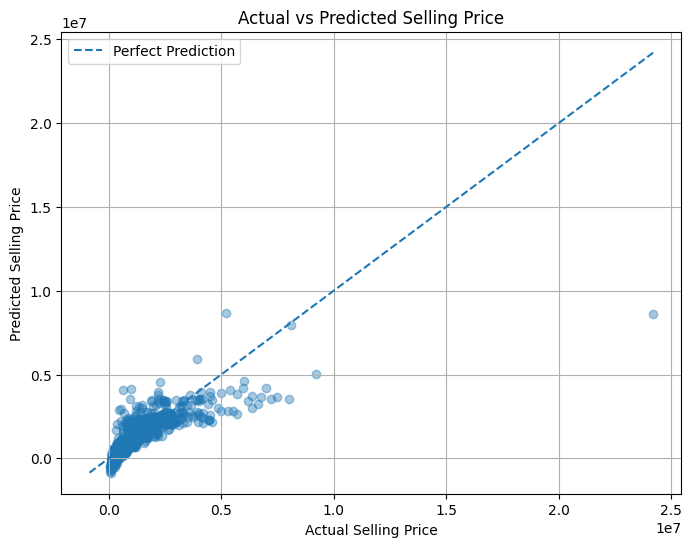

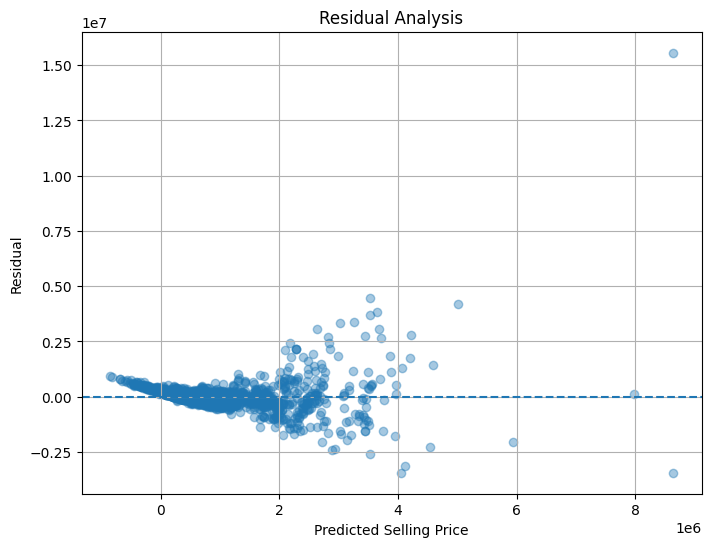

Top 10 largest prediction errors:


,Actual_Selling_Price,Predicted_Selling_Price,Residual,Squared_Error,Absolute_Error
2796,24200000.0,8.634094e+06,1.556591e+07,2.422974e+14,1.556591e+07
1382,8000000.0,3.519014e+06,4.480986e+06,2.007923e+13,4.480986e+06
2362,9200000.0,5.014409e+06,4.185591e+06,1.751917e+13,4.185591e+06
841,7500000.0,3.645724e+06,3.854276e+06,1.485545e+13,3.854276e+06
1286,7199000.0,3.519014e+06,3.679986e+06,1.354230e+13,3.679986e+06
2050,5200000.0,8.640054e+06,-3.440054e+06,1.183397e+13,3.440054e+06
26,625000.0,4.056293e+06,-3.431293e+06,1.177377e+13,3.431293e+06
1092,6645000.0,3.249227e+06,3.395773e+06,1.153128e+13,3.395773e+06
2683,6350000.0,3.019169e+06,3.330831e+06,1.109443e+13,3.330831e+06
2528,999000.0,4.113430e+06,-3.114430e+06,9.699676e+12,3.114430e+06



Model Performance Summary
RSS: 773151628691525.1
R²: 0.6788417254910979


In [54]:
# Task 19: Visualize and Analyze Model Performance

plt.figure(figsize=(8, 6))
plt.scatter(ytest, y_pred, alpha=0.4)
minimum = min(ytest.min(), y_pred.min())
maximum = max(ytest.max(), y_pred.max())
plt.plot([minimum, maximum], [minimum, maximum], linestyle="--", label="Perfect Prediction")
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.4)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Selling Price")
plt.ylabel("Residual")
plt.title("Residual Analysis")
plt.grid(True)
plt.show()

prediction_comparison["Absolute_Error"] = np.abs(residuals)
largest_errors = prediction_comparison.sort_values(by="Absolute_Error", ascending=False)
print("Top 10 largest prediction errors:")
display(largest_errors.head(10))

print("\nModel Performance Summary")
print("RSS:", RSS)
print("R²:", R_squared)

### Task 20: Conclude
•
Comment on the most influential features.

•
Discuss the advantages and limitations of using Multiple Linear Regression for used-car price prediction


### Conclusion
Conclude the experiment by stating whether the Multiple Linear Regression model implemented using the OLS normal equation was able to predict used-car selling prices effectively. The conclusion should include the obtained RSS and R² values, observations regarding important features, the effect of preprocessing and feature engineering, and the limitations of using a linear regression model for real-world used-car price prediction.